In [1]:
##Activations, Gradients, Batchnormalisation


### https://www.cs.toronto.edu/~bonner/courses/2014s/csc321/readings/sutskever2011icml.pdf
#Recurrant Neural nets (RNN) to generate text.

#https://arxiv.org/pdf/1406.5679


In [144]:
###following on some of the model from L3

import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt 
%matplotlib inline

In [145]:
words = open('names.txt', 'r').read().splitlines()
print(words[:8], len(words))

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [147]:
# vocab of char mappings against integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)
print(itos, vocab_size)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'} 27


In [148]:
##Building dataset. (with 3 splits)

block_size = 3 

def build_dataset(words):
    
    X,Y = [], []
    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix] 
            
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [149]:
n_embd = 10
n_hidden = 200

g = torch.Generator().manual_seed(2147483647)
C = torch.randn((vocab_size, n_embd),             generator=g)
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g) * (5/3) / (n_embd * block_size)**0.5 #scale hpreact away from tanh edges. 0.1 was all black# 

#wasteful as biases now useless. (mean subtraction in the batch norm)
#b1 = torch.randn(n_hidden,                        generator=g) * 0.01 ##scale hpreact away from tanh edges.

W2 = torch.randn((n_hidden, vocab_size),          generator=g) * 0.01 ###scale init weights.
b2 = torch.randn(vocab_size,                      generator=g) * 0 ###init bias 0

bngain = torch.ones((1, n_hidden)) # scale & shift step of batch normalization.
bnbias = torch.zeros((1, n_hidden)) ##added to parameters because they are trained with back propagation.

bnmean_running = torch.zeros((1, n_hidden)) #
bnstd_running = torch.ones((1, n_hidden))

parameters = [C, W1, W2, b2, bngain, bnbias]  #b1, ###using bnbias instead.
print(sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad = True

12097


In [150]:
#optimisation
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps): 
    
    #minibatch construction
    ix = torch.randint(0, Xtr.shape[0], (batch_size,))
    Xb, Yb = Xtr[ix], Ytr[ix] #batch X, Y

    #forward pass
    emb = C[Xtr[ix]] # embed charachters into vectors
    embcat = emb.view(emb.shape[0], -1) #concatenate the vectors
    hpreact = embcat @ W1 #+ b1 # #hidden layer pre-activation ####move closer to 1 to remove extreme tanh values.

    ##-------- Batch norm layer.
    bnmeani = hpreact.mean(0, keepdim=True)
    bnstdi = hpreact.std(0, keepdim=True)

    hpreact = bngain * (hpreact - bnmeani)/bnstdi + bnbias #batch normalization layer

    ##Keep track and update a smoothed running mean outside of normal training. 
    with torch.no_grad():
        bnmean_running = 0.999 * bnmean_running + 0.001 * bnmeani #### this is batchnorm 1D in torch with momentum=0.001
        bnstd_running = 0.999 * bnstd_running + 0.001 * bnstdi ##if momentum is too high mean & std will thrash around in training.
    ##--------
    
    h = torch.tanh(hpreact) #hidden layer activation 
    logits = h @ W2 + b2 # output layer
    loss = F.cross_entropy(logits, Yb) # loss function

    #backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    
    #update
    lr = 0.1 if i < 100000 else 0.01 #step rate learning decay.
    for p in parameters:
        p.data += -lr * p.grad

    #record
    if i % 10000 == 0:
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())

    
    #break

      0/ 200000: 3.2618
  10000/ 200000: 2.3183
  20000/ 200000: 2.5107
  30000/ 200000: 2.2335
  40000/ 200000: 2.1315
  50000/ 200000: 2.5000
  60000/ 200000: 2.3268
  70000/ 200000: 2.2399
  80000/ 200000: 2.2689
  90000/ 200000: 2.1001
 100000/ 200000: 2.4454
 110000/ 200000: 2.0394
 120000/ 200000: 2.3945
 130000/ 200000: 2.4024
 140000/ 200000: 2.0836
 150000/ 200000: 2.2421
 160000/ 200000: 1.7330
 170000/ 200000: 1.9149
 180000/ 200000: 2.4339
 190000/ 200000: 2.2356


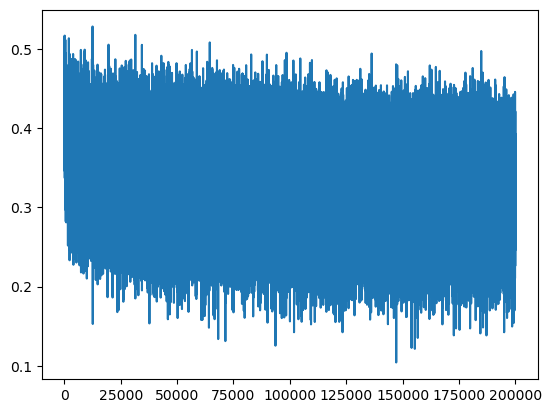

In [151]:
plt.plot(lossi) ###initla loss is high 0/ 200000: 20.0541,  190000/ 200000: 1.8810 shouldn't be x10 of the final.

In [152]:
# calibrating the batch norm at the end of training.
##explicit etimation of bnmean
with torch.no_grad():
    # pass the training set through
    emb = C[Xtr]
    embcat = emb.view(emb.shape[0], -1)
    hpreact = embcat @ W1 + b1
    # measure the mean/std over the entire training set
    bnmean = hpreact.mean(0, keepdim=True)  ###but do this in a running matter alongside training.
    bnstd = hpreact.std(0, keepdim=True)
    

In [153]:
#running updates are similar enough...
bnmean

tensor([[-2.1218,  0.4395, -1.2013,  0.8460,  0.7164,  0.6296,  1.8640, -2.1600,
          0.5540,  0.9073, -1.4261, -2.5596, -0.1074, -0.9453, -0.2272, -0.8234,
          0.8019, -1.0319, -1.2569,  1.3830, -0.4703, -0.0836, -0.6216,  0.1287,
          1.0612,  0.4571,  1.8226, -0.1922,  0.9873,  1.9118, -0.4343, -1.0056,
          0.0814, -0.1770, -0.4228, -1.1805, -2.5429,  0.6235,  0.0674,  0.0154,
         -0.1026, -0.5602, -0.5255, -0.0751,  0.4355,  0.5288,  1.0307, -1.2269,
          2.6863,  0.9739,  2.0419,  0.2259,  1.9014,  1.2484,  0.5670, -2.9926,
         -0.6179,  0.4013,  1.5560, -0.6283, -0.9703,  1.2215,  0.6330,  0.1649,
          1.0545,  1.0332, -0.5214,  1.1154, -0.5463, -0.2847, -0.7114, -0.1929,
          0.8419, -1.9765, -1.6090,  0.6428,  1.6045, -0.5671,  1.2552,  0.9482,
          0.9775,  1.2728,  0.7944,  1.2018,  0.6341, -0.4911, -0.5153, -0.1134,
          0.9839, -0.3125, -1.4213,  0.7522, -0.9395, -1.2179, -0.0087,  0.5474,
          0.7505, -1.0761,  

In [154]:
bnmean_running

tensor([[-2.1033,  0.4481, -1.2041,  0.8083,  0.7214,  0.6023,  1.8673, -2.1580,
          0.5839,  0.8935, -1.4445, -2.5489, -0.1163, -0.9436, -0.2593, -0.8168,
          0.8288, -1.0235, -1.2559,  1.3712, -0.4724, -0.1006, -0.6161,  0.1259,
          1.0583,  0.4239,  1.7984, -0.1813,  0.9780,  1.9155, -0.4475, -1.0051,
          0.0565, -0.1794, -0.4161, -1.1653, -2.5188,  0.6403,  0.0539, -0.0103,
         -0.1088, -0.5616, -0.5537, -0.0445,  0.4535,  0.5100,  1.0474, -1.2334,
          2.6905,  0.9711,  2.0557,  0.2403,  1.8936,  1.2287,  0.5760, -3.0043,
         -0.6330,  0.4008,  1.5525, -0.6579, -0.9723,  1.2303,  0.6285,  0.1723,
          1.0400,  1.0306, -0.5424,  1.1316, -0.5350, -0.2748, -0.7512, -0.1771,
          0.8286, -1.9516, -1.5950,  0.6447,  1.5998, -0.5633,  1.2532,  0.9304,
          0.9497,  1.2633,  0.8102,  1.2032,  0.6570, -0.4844, -0.5250, -0.1250,
          1.0061, -0.3055, -1.4448,  0.7315, -0.9546, -1.2385, -0.0408,  0.5477,
          0.7467, -1.0641,  

In [155]:
bnstd

tensor([[2.4447, 2.0117, 2.0312, 2.0491, 2.2133, 2.3859, 2.1547, 2.2836, 2.3462,
         2.0099, 2.5416, 2.2721, 2.2399, 2.1708, 2.1826, 2.8400, 2.3521, 1.9920,
         2.1423, 2.4488, 2.3050, 2.2209, 2.1661, 2.2089, 2.1634, 1.8618, 2.1576,
         2.2935, 2.4604, 2.3354, 1.8871, 2.0644, 2.1327, 1.9615, 2.0194, 1.9204,
         2.7051, 2.2421, 1.6498, 1.7124, 2.1103, 1.9621, 2.3646, 1.7780, 2.2727,
         2.4696, 2.1324, 2.7939, 1.8646, 2.4064, 2.2095, 1.7602, 1.9542, 1.7151,
         2.3846, 2.3201, 1.9539, 2.2236, 2.5068, 1.8035, 2.0013, 2.0463, 1.9317,
         2.3744, 2.2878, 2.1029, 1.9489, 2.3053, 2.1060, 2.1989, 2.2371, 1.9033,
         2.0659, 2.2363, 1.8400, 1.7441, 2.3970, 2.3226, 2.2100, 2.4780, 1.7945,
         2.1479, 2.1390, 2.3599, 2.3028, 2.2314, 2.1644, 2.3955, 2.1314, 2.5581,
         2.1109, 1.9647, 2.1396, 1.9399, 2.1414, 2.4238, 1.8899, 2.0406, 2.1107,
         2.2455, 2.6907, 2.0625, 2.1326, 1.9259, 2.1229, 2.2276, 2.0201, 2.1763,
         2.0804, 2.0326, 2.4

In [156]:
bnstd_running

tensor([[2.4217, 1.9949, 2.0202, 2.0354, 2.1906, 2.3655, 2.1303, 2.2495, 2.3209,
         1.9867, 2.5130, 2.2501, 2.2052, 2.1342, 2.1605, 2.8017, 2.3246, 1.9734,
         2.1189, 2.4286, 2.2927, 2.1790, 2.1433, 2.1851, 2.1422, 1.8387, 2.1325,
         2.2714, 2.4195, 2.3105, 1.8821, 2.0478, 2.1155, 1.9385, 2.0034, 1.9075,
         2.6943, 2.2310, 1.6355, 1.6997, 2.0881, 1.9427, 2.3461, 1.7627, 2.2491,
         2.4510, 2.1111, 2.7283, 1.8431, 2.3952, 2.1919, 1.7275, 1.9365, 1.7012,
         2.3552, 2.2952, 1.9474, 2.2094, 2.4742, 1.7788, 1.9819, 2.0389, 1.9138,
         2.3445, 2.2692, 2.0863, 1.9286, 2.2804, 2.0882, 2.1746, 2.2084, 1.8797,
         2.0549, 2.2173, 1.8203, 1.7187, 2.3728, 2.3070, 2.1908, 2.4429, 1.7782,
         2.1286, 2.0983, 2.3453, 2.2765, 2.2066, 2.1524, 2.3783, 2.1214, 2.5405,
         2.0917, 1.9431, 2.1254, 1.9174, 2.1245, 2.4079, 1.8603, 2.0200, 2.0887,
         2.2400, 2.6538, 2.0370, 2.1139, 1.9151, 2.1092, 2.2051, 2.0060, 2.1585,
         2.0441, 2.0208, 2.4

In [157]:
##Decorator notes##torch won't keep gradients (requires_grad = False) ie. can't do backwards pass.
@torch.no_grad() # this decorator disables gradient tracking 
def split_loss(split):
    x,y = {
        'train': (Xtr, Ytr),
        'val': (Xdev, Ydev),
        'test' : (Xte, Yte),
    }[split]
    emb = C[x] # (N, block_size, n_embd)
    embcat = emb.view(emb.shape[0], -1) ###as above
    hpreact = embcat @ W1 + b1
    #hpreact = ((hpreact - hpreact.mean(0, keepdim=True)) / hpreact.std(0,keepdim=True)) * bngain + bnbias #batch normalization layer
    hpreact = bngain * (hpreact - bnmean_running) / bnstd_running + bnbias
    h = torch.tanh(hpreact) #(N, n_hidden)
    logits = h @ W2 + b2 # output layer (N, vocab_size)
    loss = F.cross_entropy(logits, y)
    print(split, loss.item())

split_loss('train')
split_loss('val')

#train 2.0380163192749023
#val 2.1031296253204346
#
##batch normalisation
#train 2.0649404525756836
#val 2.1236491203308105
#
#train 2.064213275909424
#val 2.1223373413085938

train 2.06796932220459
val 2.1107020378112793


In [160]:
##reproducing results
g = torch.Generator().manual_seed(2147483657)

for _ in range(20):
    out = []
    context = [0] * block_size
    while True:
        emb = C[torch.tensor([context])]
        h = torch.tanh(emb.view(1, -1) @ W1 + b1)
        #h = torch.tanh(hpreact)
        logits = h @ W2 + b2
        probs = F.softmax(logits, dim=1)
        ix = torch.multinomial(probs, num_samples=1, generator=g).item()
        context = context[1:] + [ix]
        out.append(ix)
        if ix == 0:
            break
    print(''.join(itos[i] for i in out))

carpavfarrynl.
khlimriz.
thlykhllanslejmahntraquesvithlaquignnkotif.
chrihmdys.
khyld.
lughkandquinton.
lillanyad.
quinton.
giatriximfindhvitsablex.
tai.
qtettel.
thfaylahasnbtyriqsyad.
malosolswn.
ljennykasdre.
qepw.
adln.
wynordsttonyzhrinel.
qlllistrav.
khailyoqufrynn.
dayap.


In [36]:
##################################NEW MATERIAL FROM HERE 

In [37]:
#how to improve the initial state - we could use uniform probability for initial probability 
#- random NN parameters is worse than uniform accross leters

In [38]:
-torch.tensor(1/27).log()  ## initial loss is ~20

tensor(3.2958)

In [39]:
# 4 D example of the issue
logits = torch.tensor([0.0,0.0,0.0,0.0])
probs = torch.softmax(logits,dim=0)
loss = -probs[2].log()
probs, loss

(tensor([0.2500, 0.2500, 0.2500, 0.2500]), tensor(1.3863))

In [40]:
logits = torch.tensor([-3.,5.0,0.0,2.0])
probs = torch.softmax(logits,dim=0)
loss = -probs[2].log()
probs, loss

(tensor([3.1741e-04, 9.4620e-01, 6.3754e-03, 4.7108e-02]), tensor(5.0553))

In [41]:
logits = torch.randn(4) *10
probs = torch.softmax(logits,dim=0)
loss = -probs[2].log()
probs, loss

(tensor([4.9145e-08, 1.0000e+00, 3.1413e-07, 4.1999e-09]), tensor(14.9734))

In [42]:
##logits should be equal initially. 

logits = torch.tensor([5.0,5.0,5.0,5.0])
probs = torch.softmax(logits,dim=0)
loss = -probs[2].log()
probs, loss

##Not arbitrary +/- number we want them to be 0. 

(tensor([0.2500, 0.2500, 0.2500, 0.2500]), tensor(1.3863))

In [43]:
#####*alterend initial networl above , *0.1, *0
###no longer a hockey stick on the lossi plot. 


In [44]:
#####next issue,
##values of h
h

tensor([[ 1.4208e-01,  6.1630e-01, -9.6191e-01,  7.9495e-01,  8.9813e-01,
         -1.4439e-02,  4.1146e-01,  3.8351e-02,  2.6426e-01, -2.1201e-01,
         -8.0918e-01, -6.3624e-01,  6.5821e-01, -6.8918e-01,  7.5691e-02,
         -3.1322e-01,  8.5106e-01, -8.1190e-01, -6.8117e-01, -1.3878e-01,
          4.9765e-01,  9.2733e-01, -4.2671e-01, -9.4640e-01,  8.9449e-01,
         -6.3466e-01,  6.9961e-01, -3.3241e-01,  2.6787e-01, -8.5707e-02,
          6.6828e-01, -4.6142e-01,  3.0452e-01, -5.1779e-01,  5.7119e-01,
         -8.2972e-01,  8.0257e-01, -5.1181e-02,  7.4565e-01, -4.6093e-01,
         -2.5179e-02, -5.4104e-01,  2.9891e-01,  9.8137e-01,  7.1069e-01,
         -4.6615e-01, -8.3646e-02,  3.7723e-01,  3.3671e-02,  1.0595e-01,
         -4.3554e-01, -6.4631e-01,  8.2010e-01,  8.3198e-01, -7.0244e-01,
         -7.1207e-01,  7.1223e-02, -8.8342e-01,  2.7993e-01, -6.6596e-01,
         -5.0457e-01, -4.5250e-01,  9.0781e-01,  6.1150e-01,  7.4746e-01,
          5.6603e-01,  3.8555e-01, -4.

In [45]:
###alot are +/- 1.0

(array([6., 5., 3., 4., 3., 0., 1., 3., 4., 4., 3., 4., 3., 7., 6., 2., 3.,
        2., 2., 5., 0., 4., 4., 3., 6., 2., 4., 5., 3., 1., 1., 7., 4., 1.,
        4., 8., 2., 3., 2., 5., 4., 5., 8., 6., 6., 7., 3., 9., 5., 8.]),
 array([-0.98346967, -0.94386602, -0.90426238, -0.86465874, -0.8250551 ,
        -0.78545146, -0.74584782, -0.70624418, -0.66664054, -0.6270369 ,
        -0.58743325, -0.54782961, -0.50822597, -0.46862233, -0.42901869,
        -0.38941505, -0.34981141, -0.31020777, -0.27060413, -0.23100049,
        -0.19139684, -0.1517932 , -0.11218956, -0.07258592, -0.03298228,
         0.00662136,  0.046225  ,  0.08582864,  0.12543228,  0.16503592,
         0.20463957,  0.24424321,  0.28384685,  0.32345049,  0.36305413,
         0.40265777,  0.44226141,  0.48186505,  0.52146869,  0.56107234,
         0.60067598,  0.64027962,  0.67988326,  0.7194869 ,  0.75909054,
         0.79869418,  0.83829782,  0.87790146,  0.9175051 ,  0.95710875,
         0.99671239]),
 <BarContainer object

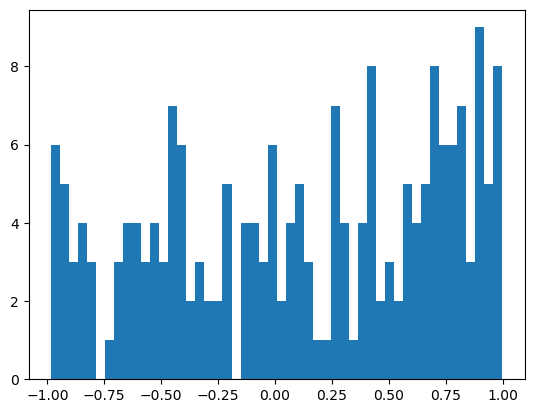

In [46]:
plt.hist(h.view(-1).tolist(),50)

(array([  2.,   0.,   3.,   9.,   9.,  15.,  19.,  18.,  25.,  56.,  63.,
         83., 127., 156., 188., 237., 285., 322., 331., 363., 419., 384.,
        421., 416., 380., 333., 288., 289., 261., 196., 180., 141.,  79.,
         92.,  60.,  33.,  38.,  19.,  19.,  15.,   6.,  12.,   2.,   2.,
          1.,   0.,   0.,   1.,   0.,   2.]),
 array([-3.70206761, -3.53259833, -3.36312904, -3.19365976, -3.02419047,
        -2.85472119, -2.6852519 , -2.51578262, -2.34631333, -2.17684405,
        -2.00737476, -1.83790548, -1.66843619, -1.49896691, -1.32949762,
        -1.16002834, -0.99055905, -0.82108977, -0.65162048, -0.4821512 ,
        -0.31268191, -0.14321263,  0.02625666,  0.19572594,  0.36519523,
         0.53466451,  0.7041338 ,  0.87360308,  1.04307237,  1.21254165,
         1.38201094,  1.55148022,  1.72094951,  1.89041879,  2.05988808,
         2.22935736,  2.39882665,  2.56829593,  2.73776522,  2.9072345 ,
         3.07670379,  3.24617307,  3.41564236,  3.58511164,  3.75458093,
 

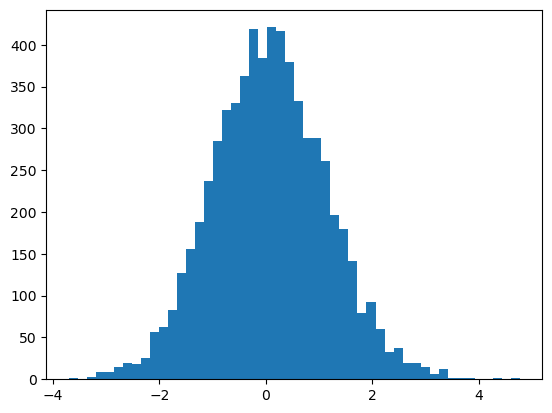

In [47]:
###look at preactivations that feed into tanh.
plt.hist(hpreact.view(-1).tolist(),50)

In [48]:
###which is quite broad. 
####you do not want lots of values at max/min weights.


In [49]:
#a lot of cases have the gradient destroyed. 

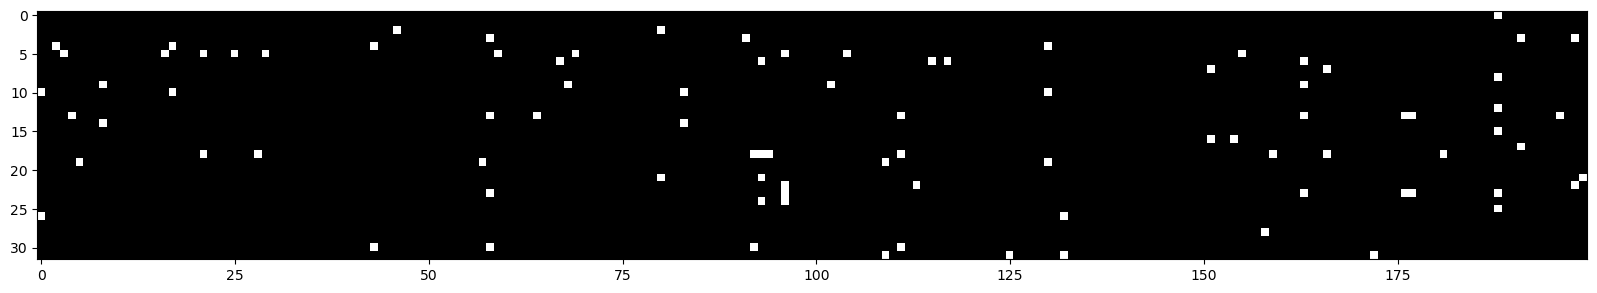

In [52]:
plt.figure(figsize=(20,10))
plt.imshow(h.abs()> 0.99, cmap='gray', interpolation='nearest')
##white blue for 32 exampls in 200 hidden neurons. a lot of the neurons are active and in the flat tails. 

In [27]:
#If a whole column is white or black in the pixel then its called a 'dead' neuron, and no inputs pass through (it won't learn here.
#Same is true for sigmoid, and ReLU.

###need leaky ReLU or ELU, they don't have zero areas - the edges are near 1 or zero so you can never have dead neurons.


In [28]:
###lets update the network to fix this. adjust hpreact closer to 0. 


In [ ]:
##all black isn't good either column#### W* 0.2 looks good. 

In [57]:
####but we've added magic numbers to the network construction to fix this.

In [64]:
n = 10**0.5  #0.2 -- smaller s.d. #10 - bigger s.d.
x = torch.randn(1000, 10)
w = torch.randn(10, 200) * 1/n
y = x @ w
print(x.mean(), x. std())
print(y.mean(), y.std())

tensor(0.0037) tensor(1.0112)
tensor(3.5637e-05) tensor(0.9996)


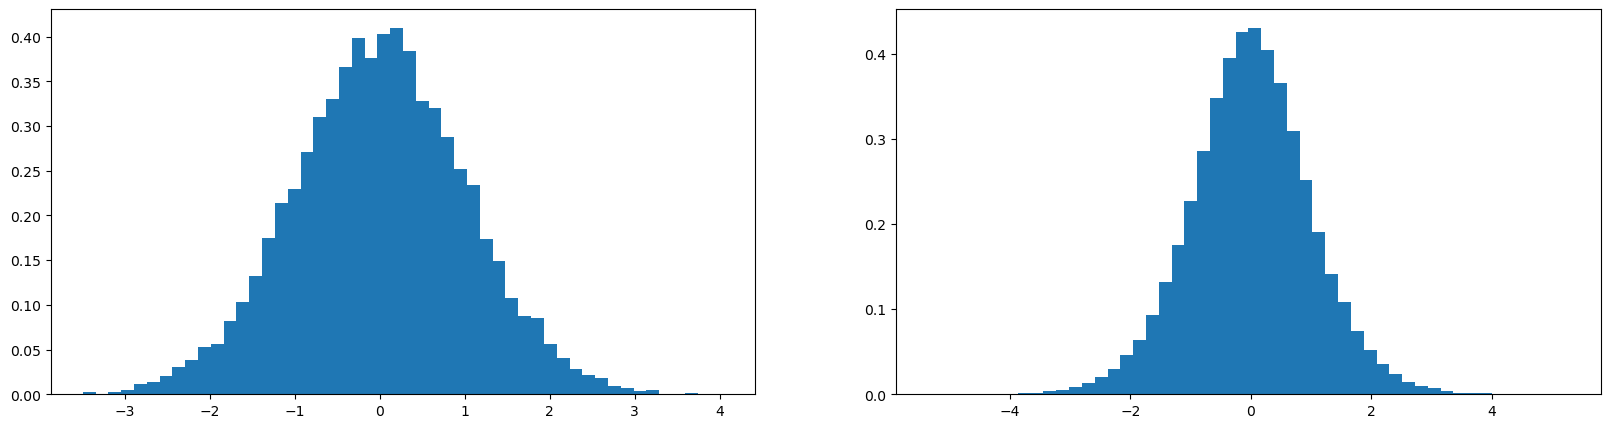

In [65]:
plt.figure(figsize=(20,5))
plt.subplot(121)
plt.hist(x.view(-1).tolist(), 50, density=True);
plt.subplot(122)
plt.hist(y.view(-1).tolist(),50,density=True);

In [66]:
###consider randomly drawn gaussian layers. 
##Gaussian expands from L ro R plot due to the matmul (@) of weighting layer.
#### scaling w * N, you can reduce the S.D. of the output gaussian.
#so what do you need N to be to preserve the output?
#---->    sqrt width of input elements for the network (aka fan in). (Kaiming paper) 

"fan-in is the number of incoming input connections feeding into a specific neuron or layer"

In [ ]:
##3 further innovations to help network adapt for bad initialisations.

## residual collections
## normalisation layers (batch, layer group normalisations)
## better optimisers. (arm as prop & adam). 

In [68]:
### for tanh you need gain 5/3.  AND We'll use the Kaiming norm.  https://docs.pytorch.org/docs/2.14/nn.init.html
(torch.randn(10000) * 0.2).std()

tensor(0.1966)

In [71]:
(5/3) / (n_embd * block_size)**0.5  ###fan in ###now added to network construc tion

0.3042903097250923

In [78]:
##take the hidden states and normalise them to unit Gaussian. (its differentiable so its fine). 

In [79]:
##hpreact needs to be roughly gaussian. 
hpreact.shape

torch.Size([32, 200])

In [80]:
hpreact.mean(0, keepdim=True).shape

torch.Size([1, 200])

In [81]:
hpreact.std(0, keepdim=True).shape

torch.Size([1, 200])

In [89]:
###but don't want to be forced to be gaussian always.. just at the start, then flexible dependent on the back propagation. 
##"scale and shift" step from the paper.  y <- gain * scale + bias

## scale is normalized hpreact = (hpreact - hpreact.mean(0, keepdim=True))/hpreact.std(0,keepdim=True)

In [121]:
### but batch normalisation has a cost...
# coupling examples mathematically in the forward pass (and also therefore backward) - noone likes this
###now a function of all random samples in each batch. 
#jitter within any sample depending its a signed batch (in h and logits). 
### accidently its good. its a regularizer. padds out the input examples with entropy. 
#NN finds it harder to over fit when regularization occurs. 

###batch normalization actually makes it worse.. but 

###other normalisations aim to fix this. but it stabalizes training. -- best network output is worse but each network run is less random. 

In [143]:
#offset of +epsilon in denominator of the normalisation can prevent undefined division but leaving that out here. 

In [159]:
###fin and fout need to agree with matrix broadcasting. 

In [161]:
#Batchnorm

In [305]:
##
class Linear:
    """
    torch.nn.linear (omitting devices (e.g. cuda) and dtype (e.g. float double). 
    """
    def __init__(self, fan_in, fan_out, bias=True):
        self.weight = torch.randn((fan_in, fan_out), generator = g) /fan_in**0.5 #fan_in**0.5  ###commented this to show what plots do when its bad. 
        self.bias = torch.zeros(fan_out) if bias else None

    def __call__(self, x):
        self.out = x @ self.weight
        if self.bias is not None:
            self.out +=  self.bias
        return self.out

    def parameters(self):
        return [self.weight] + ({} if self.bias is None else [self.bias])

class BatchNorm1d:
    """
    torch.nn.batchnorm1d   with affine = True, track_running stats = true (device = cpu, dtype = float32). 
    """
    def __init__(self, dim, eps= 1e-5, momentum=0.1):
        self.eps = eps
        self.momentum = momentum
        self.training = True #false for evaluation. 
        # parameters (trained with backprop)
        self.gamma = torch.ones(dim)
        self.beta = torch.zeros(dim)
        #buffers (trained with a running momentum update)
        self.running_mean = torch.zeros(dim)
        self.running_var = torch.ones(dim)

    def __call__(self, x):
        #calculate the forward pass
        if self.training:
            xmean = x.mean(0, keepdim=True) #batch mean
            xvar = x.var(0, keepdim = True, unbiased = True) # batch variance
        else:
            xmean = self.running_mean
            xvar = self.running_var
        xhat = (x - xmean) / torch.sqrt(xvar + self.eps) # normalize to unit variance
        self.out = self.gamma * xhat + self.beta ###not in pytorch but helps us plot. 
        #update the training buffers
        if self.training:
            with torch.no_grad():
                self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
                self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar
        return self.out

    def parameters(self):
        return [self.gamma, self.beta] 

class Tanh:
    """
    torch.nn.Tanh
    """
    def __call__(self, x):
        self.out = torch.tanh(x)
        return self.out
    def parameters(self):
        return []

n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 100 # the number of neurons in the hidden layaer of the MLP
g = torch.Generator().manual_seed(2147483647) # for reproducibility

C = torch.randn((vocab_size, n_embd), generator=g)
layers = [
    Linear(n_embd * block_size, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    Linear(           n_hidden, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    Linear(           n_hidden, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    Linear(           n_hidden, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    Linear(           n_hidden, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    Linear(           n_hidden, vocab_size), BatchNorm1d(vocab_size)
]
##classes make the layer stacking easy, its just a list called sequentially. 
#before batchnorm1d just omit it. e.g. Linear(n_hidden, n_hidden),Tanh(),
###he also does one version with Linear(bias = False)

with torch.no_grad():
    # last layer: make less confident
    #layers[-1].weight *= 0.1     #####this leads to the pink line outlier, but it stabalises. (used this when outpu layer was Linear)
    layers[-1].gamma *= 0.1 ###because output layer is a Batchnorm, 
    # all other layers have gain applied.
    for layer in layers[:-1]:
        if isinstance(layer, Linear):
            layer.weight *= 5/3 #Linear layers + tanh gain, replenishes output s.d. to same as input. - this matters less with batch normalization. 

parameters = [C] + [p for layer in layers for p in layer.parameters()]
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
    p.requires_grad = True
    

47551


In [296]:
# some optimization as alst time.
max_steps = 200000
batch_size = 32
lossi = []
ud = []

for i in range(max_steps):

    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix] # batach, X, Y

    # forward pass
    emb = C[Xb] # embed the characters into vectors
    x = emb.view(emb.shape[0], -1) #concatenate the vectors
    for layer in layers:
        x = layer(x)
    loss = F.cross_entropy(x, Yb) # loss function

    # backward pass
    for layer in layers:
        layer.out.retain_grad() # after debugf would take out retin_graph >???
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    lr = 0.1 if i < 100000 else 0.01 # step learning rate decay.
    for p in parameters:
        p.data += -lr * p.grad

    # track stats
    if i % 10000 == 0: 
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())
    with torch.no_grad():
        ud.append([(lr*p.grad.std() / p.data.std()).log10().item() for p in parameters])
    
    #if i >=1000:
    #    break

      0/ 200000: 3.2870
  10000/ 200000: 2.3578
  20000/ 200000: 2.1043
  30000/ 200000: 1.9646
  40000/ 200000: 2.2144
  50000/ 200000: 2.2266
  60000/ 200000: 1.7339
  70000/ 200000: 2.1749
  80000/ 200000: 2.1895
  90000/ 200000: 1.8281
 100000/ 200000: 2.3634
 110000/ 200000: 2.2015
 120000/ 200000: 2.1032
 130000/ 200000: 1.8564
 140000/ 200000: 1.8051
 150000/ 200000: 1.9258
 160000/ 200000: 1.8763
 170000/ 200000: 1.8335
 180000/ 200000: 2.2314
 190000/ 200000: 2.0513


layer 2 (      Tanh): mean -0.01, std 0.69, saturated: 14.03%
layer 5 (      Tanh): mean -0.02, std 0.72, saturated: 16.91%
layer 8 (      Tanh): mean -0.00, std 0.75, saturated: 15.75%
layer 11 (      Tanh): mean +0.02, std 0.77, saturated: 16.78%
layer 14 (      Tanh): mean -0.02, std 0.79, saturated: 18.72%


Text(0.5, 1.0, 'activation distribution')

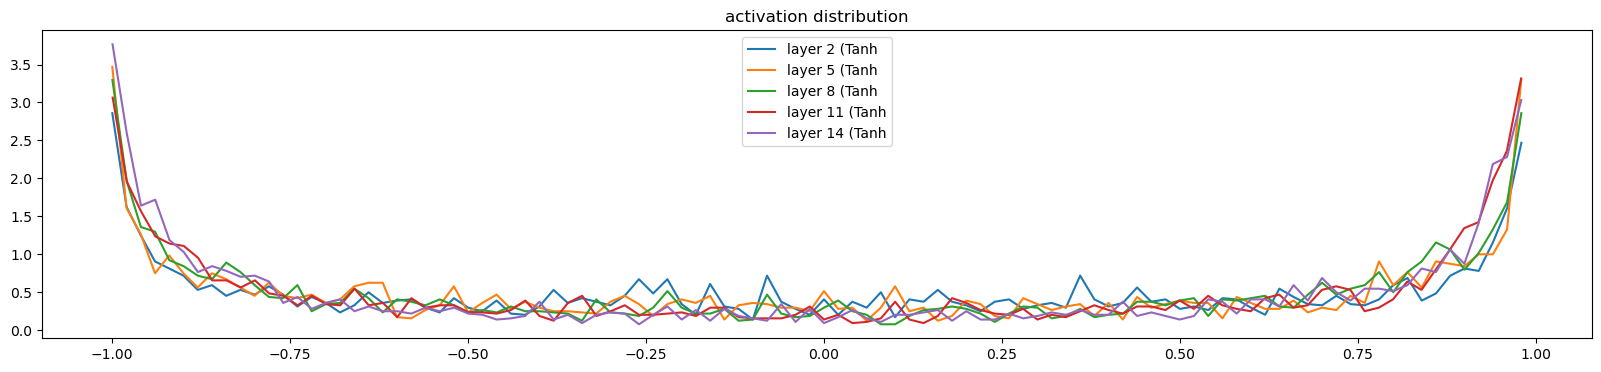

In [297]:
# visualise histograms
plt.figure(figsize = (20,4)) 
legends = []
for i, layer in enumerate(layers[:-1]): # excluding output layer.
    if isinstance(layer, Tanh):
        t = layer.out
        print('layer %d (%10s): mean %+.2f, std %.2f, saturated: %.2f%%' % (i, layer.__class__.__name__, t.mean(), t.std(), (t.abs() > 0.97).float().mean()*100))
        hy, hx = torch.histogram(t, density=True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f'layer {i} ({layer.__class__.__name__}')
plt.legend(legends);
plt.title('activation distribution')
             

layer 2 (      Tanh): mean -0.000000, std 3.413328e-03
layer 5 (      Tanh): mean +0.000000, std 3.279261e-03
layer 8 (      Tanh): mean -0.000000, std 3.260843e-03
layer 11 (      Tanh): mean -0.000000, std 3.532994e-03
layer 14 (      Tanh): mean -0.000000, std 3.843003e-03


Text(0.5, 1.0, 'activation distribution')

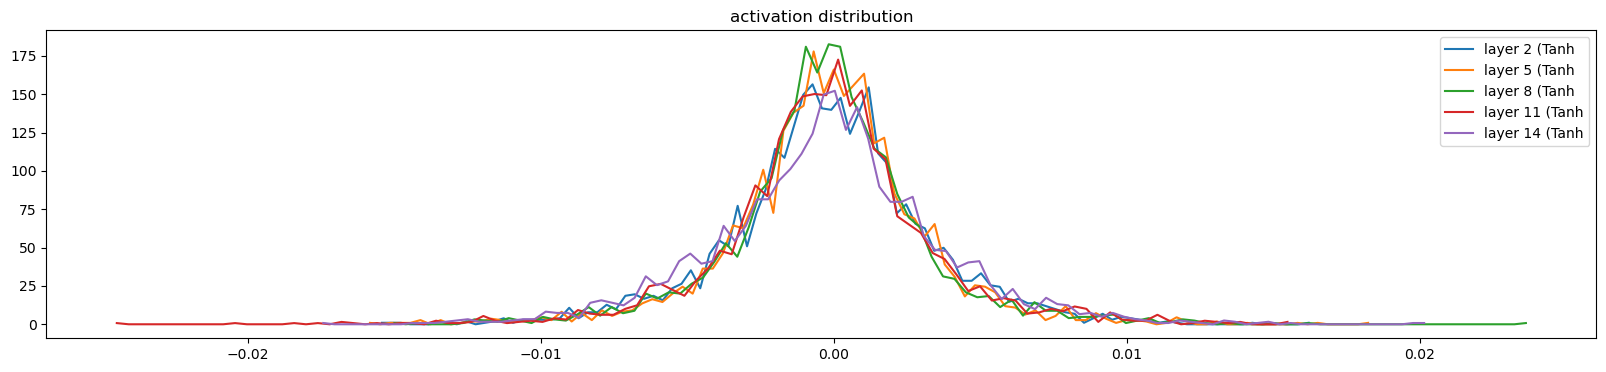

In [298]:
plt.figure(figsize = (20,4)) 
legends = []
for i, layer in enumerate(layers[:-1]): # excluding output layer.
    if isinstance(layer, Tanh):
        t = layer.out.grad
        print('layer %d (%10s): mean %+f, std %e' % (i, layer.__class__.__name__, t.mean(), t.std()))
        hy, hx = torch.histogram(t, density=True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f'layer {i} ({layer.__class__.__name__}')
plt.legend(legends);
plt.title('activation gradient distribution')

weight   (27, 10) | mean +0.000000 | std 1.496318e-02 | grad:data ratio 1.370163e-02
weight  (30, 100) | mean +0.000085 | std 7.867816e-03 | grad:data ratio 1.919648e-02
weight (100, 100) | mean +0.000060 | std 5.040184e-03 | grad:data ratio 2.041886e-02
weight (100, 100) | mean -0.000086 | std 5.160316e-03 | grad:data ratio 2.125704e-02
weight (100, 100) | mean +0.000044 | std 5.189185e-03 | grad:data ratio 2.190954e-02
weight (100, 100) | mean -0.000013 | std 5.229847e-03 | grad:data ratio 2.274837e-02
weight  (100, 27) | mean +0.000052 | std 9.163456e-03 | grad:data ratio 2.774516e-02


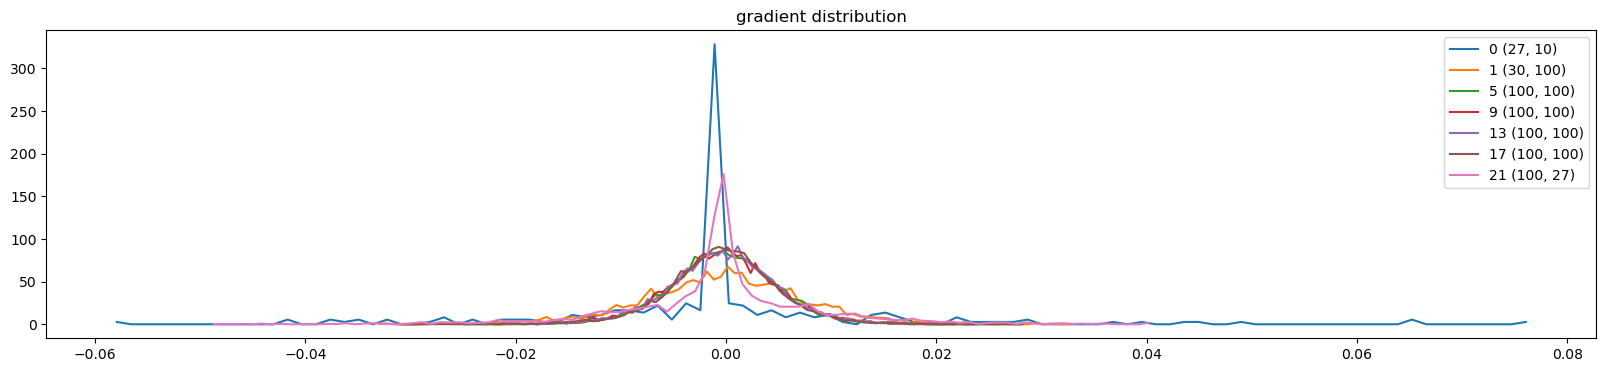

In [299]:
# visualise histograms
plt.figure(figsize = (20,4)) 
legends = []
for i,p in enumerate(parameters): 
    t = p.grad
    if p.ndim == 2:  #restricted to 2d weights of linear layer.
        print('weight %10s | mean %+f | std %e | grad:data ratio %e' % (tuple(p.shape), t.mean(), t.std(), t.std() / p.std()))
        hy, hx = torch.histogram(t, density=True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f'{i} {tuple(p.shape)}')
plt.legend(legends)
plt.title('parameters gradient distribution');

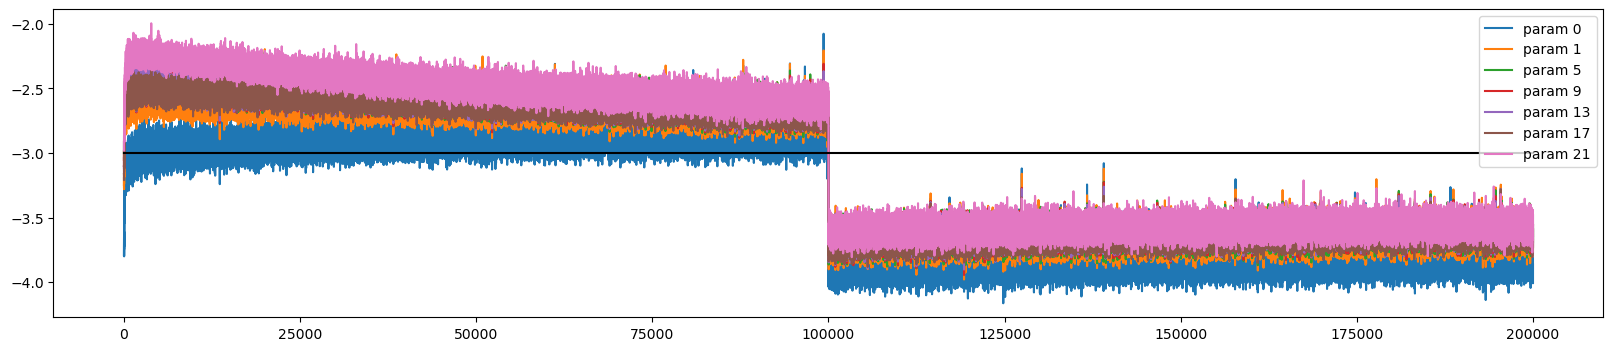

In [300]:
plt.figure(figsize=(20,4))
legends = []
for i, p in enumerate(parameters):
    if p.ndim ==2:
        plt.plot([ud[j][i] for j in range(len(ud))])
        legends.append('param %d' % i)
plt.plot([0, len(ud)], [-3,-3], 'k') # these ratios should be ~1e-3, indicated on plot
plt.legend(legends);
###slow training will have values here 10,000 times smaller than the tensor size. 
#its near the black line that things are ok. 

In [301]:
@torch.no_grad() # this decorator disables gradient tracking
def split_loss(split):
    x,y = {
        'train': (Xtr, Ytr),
        'val': (Xdev, Ydev),
        'test' : (Xte, Yte),
    }[split]
    emb = C[x] # (N, block_size, n_embd)
    x = emb.view(emb.shape[0], -1) # concat into (N, block_size, n_embd)
    for layer in layers:
        x = layer(x)
    loss = F.cross_entropy(x, y)
    print(split, loss.item())

# put layers into eval mode
for layer in layers:
    layer.training = False
    
split_loss('train')
split_loss('val')

train 2.0123209953308105
val 2.0841028690338135


In [302]:
#sample from the model
g = torch.Generator().manual_seed(2147483657)

for _ in range(20):
    out = []
    context = [0] * block_size # initialise with all...
    while True:
        # foward pass
        emb = C[torch.tensor([context])] # (1, block_size, n_embd)
        x = emb.view(emb.shape[0], -1) # concatenate the vectors
        for layer in layers:
            x = layer(x) 
        logits = x
        probs = F.softmax(logits, dim=1)
        # sample from the distribution
        ix = torch.multinomial(probs, num_samples = 1, generator=g).item()
        context = context[1:] + [ix]
        out.append(ix)
        if ix == 0:
            break
    print(''.join(itos[i] for i in out))

carlah.
amelle.
khyriri.
reity.
skanya.
eja.
hube.
deliah.
jareei.
nellara.
chaiir.
kaleigh.
ham.
joce.
quintis.
lilah.
jadiquinte.
madiaryn.
kai.
eupitraylen.


In [303]:
## He experiemnts with gain (set at 5/3) and sees how it effects the histograms. 
#(too small, too slow, too big, network expands and you get dead neurons). 

# we want the s.d. of activated NN layers to be roughly equal and to have tails of the network within the range of activations. 

## if you have no tanh,  the layers combine to a single linear combination. 


## std of input vs output in the 3rd plot...
####output layer is a trouble maker because it expands a lot so this layer trains on different timescales to the rest of the network. 

#actually most important is update to data ratio  -- so we'll add UD for a new plot. ud = []

In [304]:
##messing with the gain is usually compensatable with adjusting the learning rate.

#### we'll that later by looking at the backward pass of all the network. 
